In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/tmp/ipykernel_419784/1626899435.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use("seaborn")
/tmp/ipykernel_419784/1626899435.py:24: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use("seaborn")


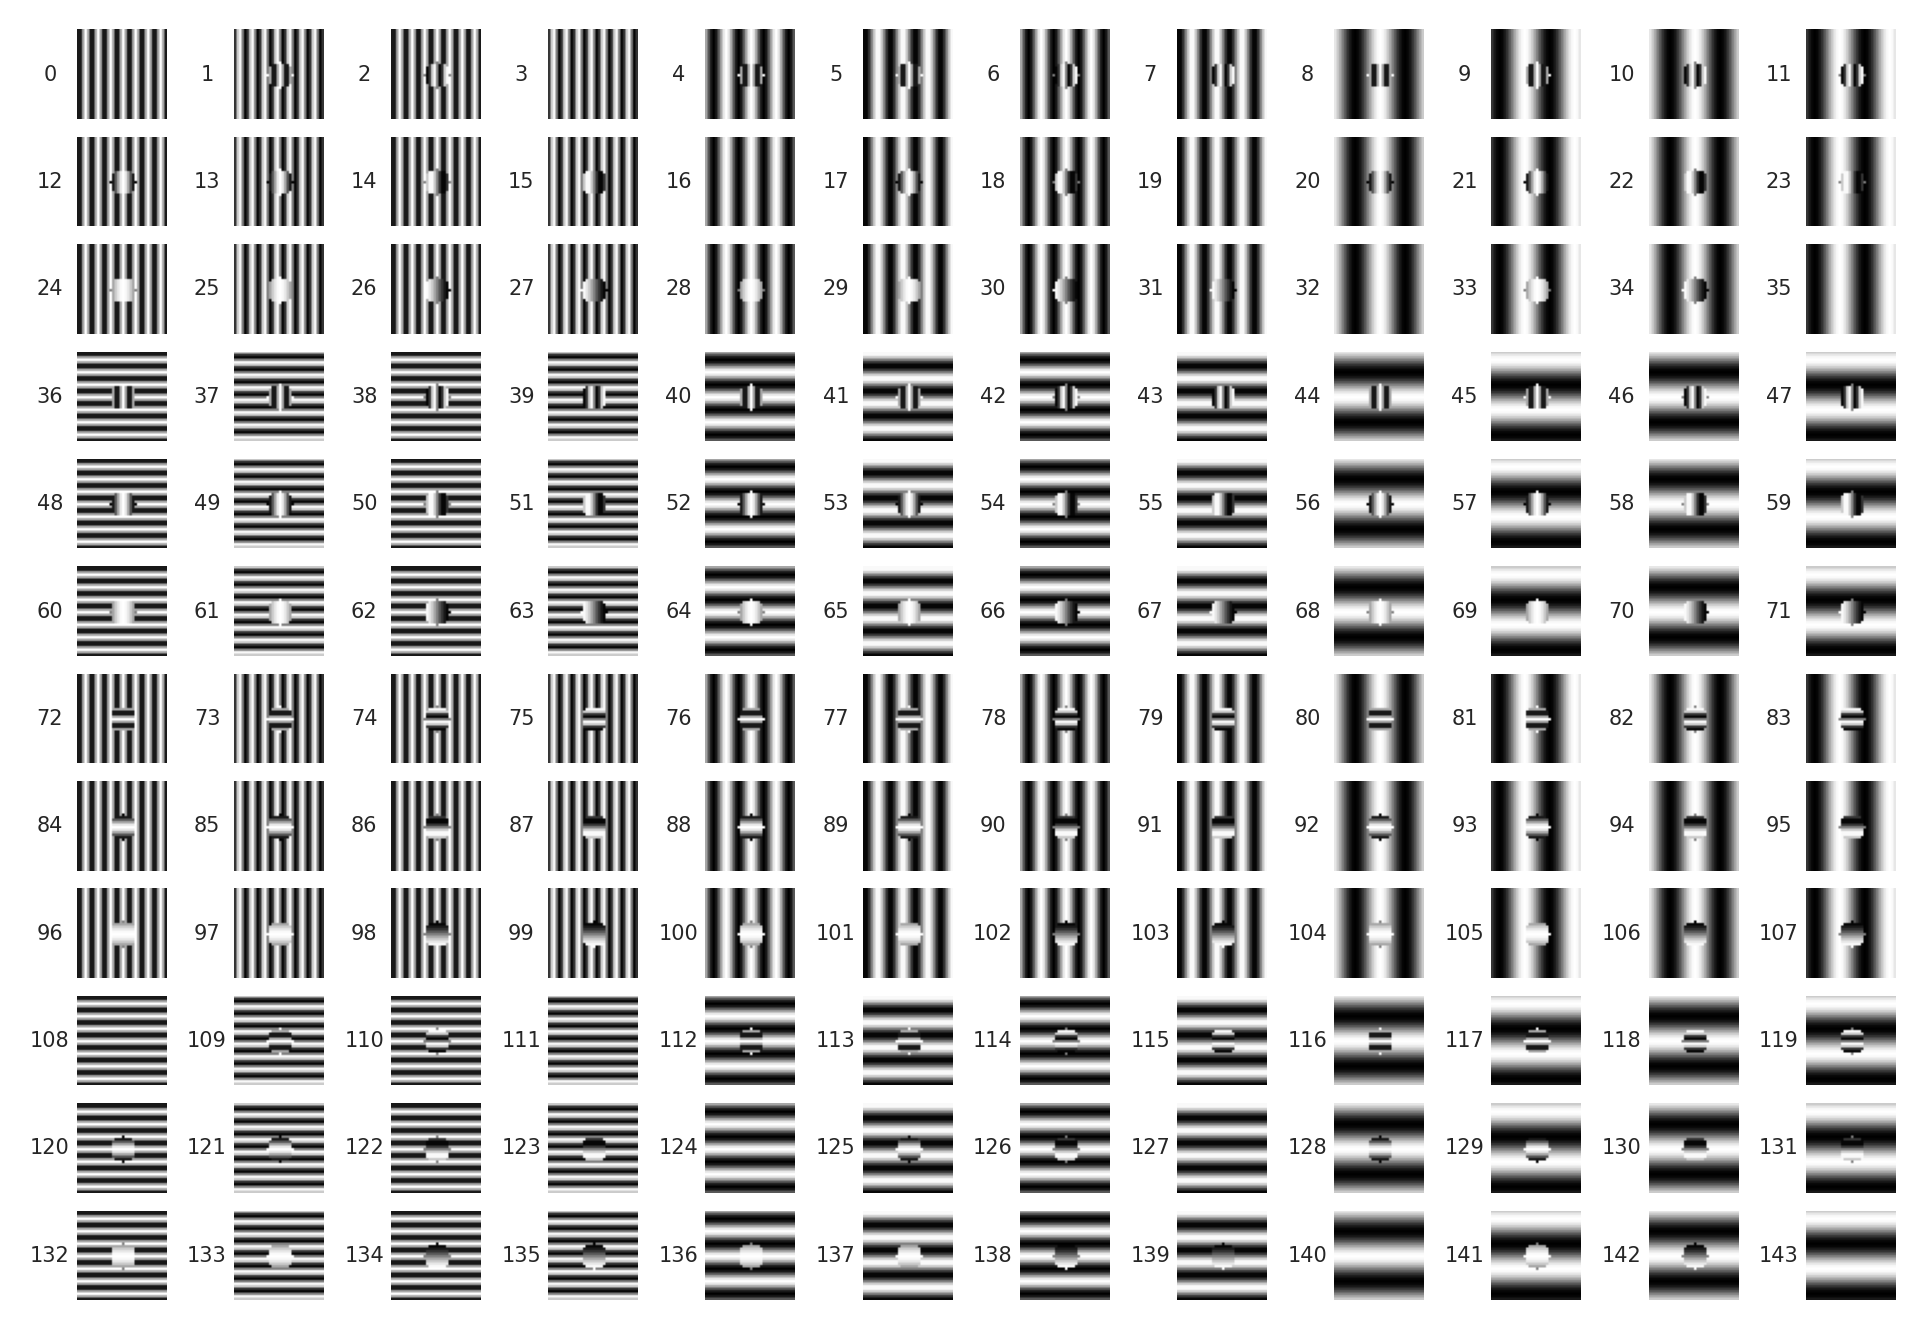

In [2]:
center_surround_params = {
    "canvas_size": [36, 36],
    "spatial_frequencies_center": [1/5, 1/10, 1/20],
    "spatial_frequencies_surround": [1/5, 1/10, 1/20],
    "phases_center": [0., np.pi/2],
    "phases_surround": [0., np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [0., np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[18, 18]],
    "sizes_total": [36],
    "sizes_center": [20/4/36],
    "sizes_surround": [20/4/36],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_surround_gabors = CenterSurround(**center_surround_params)
fig, axs = plt.subplots(12, 12, dpi=300)
for i, ax in enumerate(axs.flatten()):
    if i < center_surround_gabors.images().shape[0]:
        ax.imshow(center_surround_gabors.images()[i], cmap="gray", vmin=-1, vmax=1)
        # write the label on the left side of the subplot
        ax.text(-0.3, 0.5, f"{i}", size=5, ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

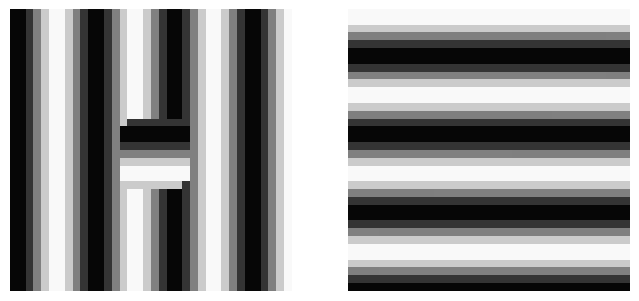

In [4]:
center_surround_params = {
    "canvas_size": [36, 36],
    "spatial_frequencies_center": [1/10],
    "spatial_frequencies_surround": [1/10],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[18, 18]],
    "sizes_total": [36],
    "sizes_center": [20/4/36],
    "sizes_surround": [20/4/36],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_surround_gabors = CenterSurround(**center_surround_params)
fig, axs = plt.subplots(2, 2, dpi=100)
for i, ax in enumerate(axs.flatten()):
    if i < center_surround_gabors.images().shape[0]:
        ax.imshow(center_surround_gabors.images()[i], cmap="gray", vmin=-1, vmax=1)
        # write the label on the left side of the subplot
        # ax.text(-0.3, 0.5, f"{i}", size=5, ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")